In [1]:
from google.colab import files
uploaded = files.upload()

Saving public_transport_delays.csv to public_transport_delays.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("public_transport_delays.csv")

df.head()

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NaN,500,46,0,0,6,Spring,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   object 
 1   date                        2000 non-null   object 
 2   time                        2000 non-null   object 
 3   transport_type              2000 non-null   object 
 4   route_id                    2000 non-null   object 
 5   origin_station              2000 non-null   object 
 6   destination_station         2000 non-null   object 
 7   scheduled_departure         2000 non-null   object 
 8   scheduled_arrival           2000 non-null   object 
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   object 
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 

In [7]:
df.describe()

,actual_departure_delay_min,actual_arrival_delay_min,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,delayed
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,8.688000,13.318000,15.121350,64.714000,29.300500,9.860700,6420.250000,50.244000,0.089500,0.272000,2.976000,0.749500
std,6.268118,9.289727,11.479424,20.334747,17.264015,5.781373,15198.306129,29.225751,0.285535,0.445101,1.990328,0.433409
min,-2.000000,-3.000000,-5.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,5.000000,5.100000,46.000000,15.000000,4.900000,0.000000,25.000000,0.000000,0.000000,1.000000,0.000000
50%,9.000000,13.000000,15.300000,65.000000,29.000000,9.700000,0.000000,50.000000,0.000000,0.000000,3.000000,1.000000
75%,14.000000,21.000000,24.800000,83.000000,45.000000,14.800000,2000.000000,76.000000,0.000000,1.000000,5.000000,1.000000
max,19.000000,29.000000,35.000000,99.000000,59.000000,20.000000,50000.000000,99.000000,1.000000,1.000000,6.000000,1.000000


In [8]:
df.isnull().sum()

,0
trip_id,0
date,0
time,0
transport_type,0
route_id,0
origin_station,0
destination_station,0
scheduled_departure,0
scheduled_arrival,0
actual_departure_delay_min,0


In [10]:
df = df.dropna()

In [14]:
df.columns

Index(['trip_id', 'date', 'time', 'transport_type', 'route_id',
       'origin_station', 'destination_station', 'scheduled_departure',
       'scheduled_arrival', 'actual_departure_delay_min',
       'actual_arrival_delay_min', 'weather_condition', 'temperature_C',
       'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_type',
       'event_attendance_est', 'traffic_congestion_index', 'holiday',
       'peak_hour', 'weekday', 'season', 'delayed'],
      dtype='object')

In [16]:
X = df.drop("actual_arrival_delay_min", axis=1)
y = df["actual_arrival_delay_min"]

In [17]:
df = df.drop(['trip_id','date','time','origin_station','destination_station',
              'scheduled_departure','scheduled_arrival'], axis=1)

In [18]:
df = pd.get_dummies(df)

In [19]:
from sklearn.model_selection import train_test_split

X = df.drop("actual_arrival_delay_min", axis=1)
y = df["actual_arrival_delay_min"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [20]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(X_train,y_train)

RandomForestRegressor()

In [21]:
predictions = model.predict(X_test)

In [25]:
print(df.columns)

Index(['actual_departure_delay_min', 'actual_arrival_delay_min',
       'temperature_C', 'humidity_percent', 'wind_speed_kmh',
       'precipitation_mm', 'event_attendance_est', 'traffic_congestion_index',
       'holiday', 'peak_hour', 'weekday', 'delayed', 'transport_type_Bus',
       'transport_type_Metro', 'transport_type_Train', 'transport_type_Tram',
       'route_id_Route_1', 'route_id_Route_10', 'route_id_Route_11',
       'route_id_Route_12', 'route_id_Route_13', 'route_id_Route_14',
       'route_id_Route_15', 'route_id_Route_16', 'route_id_Route_17',
       'route_id_Route_18', 'route_id_Route_19', 'route_id_Route_2',
       'route_id_Route_20', 'route_id_Route_3', 'route_id_Route_4',
       'route_id_Route_5', 'route_id_Route_6', 'route_id_Route_7',
       'route_id_Route_8', 'route_id_Route_9', 'weather_condition_Clear',
       'weather_condition_Cloudy', 'weather_condition_Fog',
       'weather_condition_Rain', 'weather_condition_Snow',
       'weather_condition_Storm', '

In [27]:
df = pd.get_dummies(df, drop_first=True)

In [28]:
X = df.drop("actual_arrival_delay_min", axis=1)

y = df["actual_arrival_delay_min"]

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

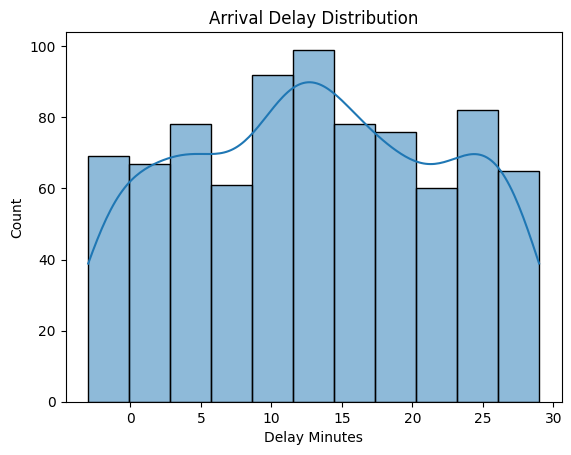

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['actual_arrival_delay_min'], kde=True)
plt.title("Arrival Delay Distribution")
plt.xlabel("Delay Minutes")
plt.show()

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [36]:
df = pd.read_csv("public_transport_delays.csv")

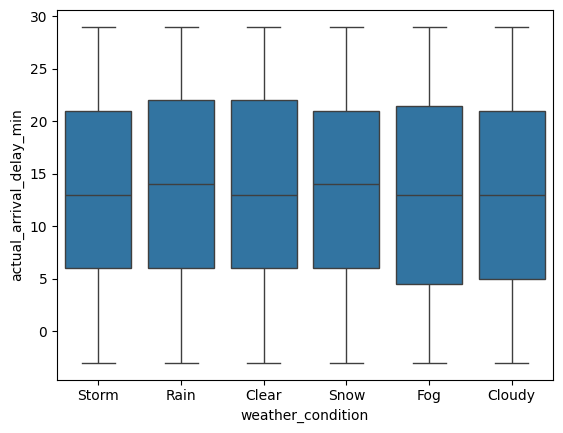

In [37]:
sns.boxplot(x='weather_condition', y='actual_arrival_delay_min', data=df)
plt.show()

In [38]:
df = pd.get_dummies(df)

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("public_transport_delays.csv")

In [43]:
print(df.columns)

Index(['trip_id', 'date', 'time', 'transport_type', 'route_id',
       'origin_station', 'destination_station', 'scheduled_departure',
       'scheduled_arrival', 'actual_departure_delay_min',
       'actual_arrival_delay_min', 'weather_condition', 'temperature_C',
       'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_type',
       'event_attendance_est', 'traffic_congestion_index', 'holiday',
       'peak_hour', 'weekday', 'season', 'delayed'],
      dtype='object')


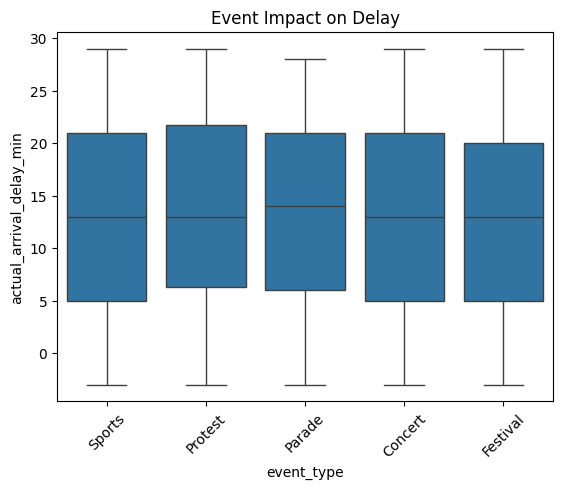

In [45]:
sns.boxplot(x='event_type', y='actual_arrival_delay_min', data=df)

plt.title("Event Impact on Delay")

plt.xticks(rotation=45)

plt.show()

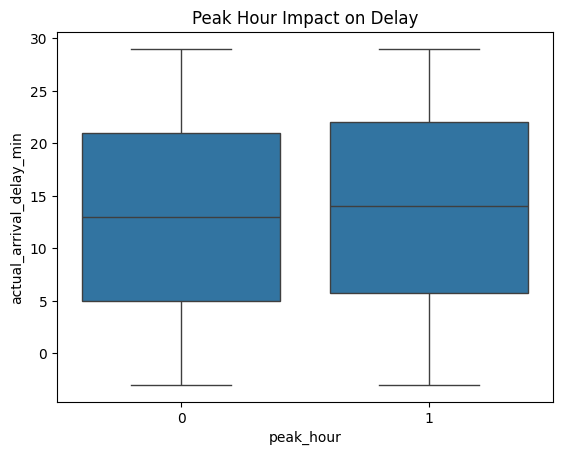

In [46]:
sns.boxplot(x='peak_hour', y='actual_arrival_delay_min', data=df)

plt.title("Peak Hour Impact on Delay")

plt.show()

In [47]:
df = df.drop(['trip_id','origin_station','destination_station',
              'scheduled_departure','scheduled_arrival',
              'date','time'], axis=1)

In [48]:
df.isnull().sum()

,0
transport_type,0
route_id,0
actual_departure_delay_min,0
actual_arrival_delay_min,0
weather_condition,0
temperature_C,0
humidity_percent,0
wind_speed_kmh,0
precipitation_mm,0
event_type,1173


In [49]:
df = df.dropna()

In [50]:
df = pd.get_dummies(df)

In [51]:
X = df.drop("actual_arrival_delay_min", axis=1)
y = df["actual_arrival_delay_min"]

In [52]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42)

In [53]:
pred = model.predict(X_test)

In [54]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test,pred)

print("Model Error:",mae)

Model Error: 5.464277108433735


In [55]:
import pandas as pd

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance.sort_values(by='Importance',ascending=False)

,Feature,Importance
10,delayed,0.597095
6,traffic_congestion_index,0.044005
4,precipitation_mm,0.043743
1,temperature_C,0.043272
2,humidity_percent,0.037519
3,wind_speed_kmh,0.035183
0,actual_departure_delay_min,0.027905
9,weekday,0.021197
5,event_attendance_est,0.016342
14,transport_type_Tram,0.007273


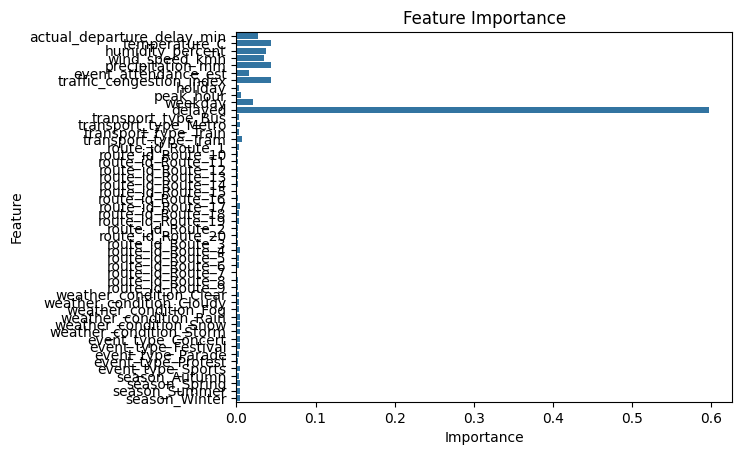

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Importance',y='Feature',data=feature_importance)

plt.title("Feature Importance")

plt.show()

In [57]:
df.to_csv("transport_delay_cleaned.csv",index=False)

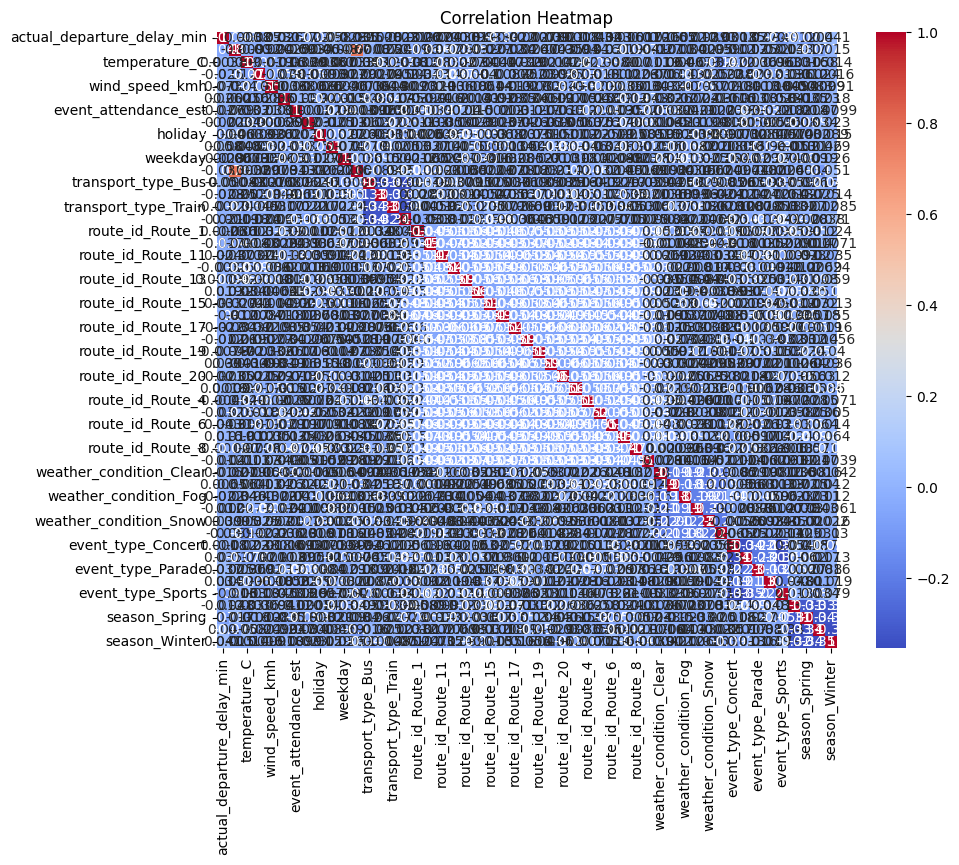

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

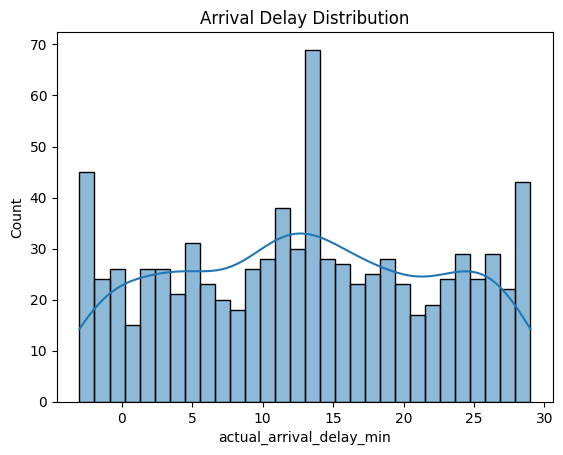

In [59]:
sns.histplot(df['actual_arrival_delay_min'],bins=30,kde=True)

plt.title("Arrival Delay Distribution")

plt.show()

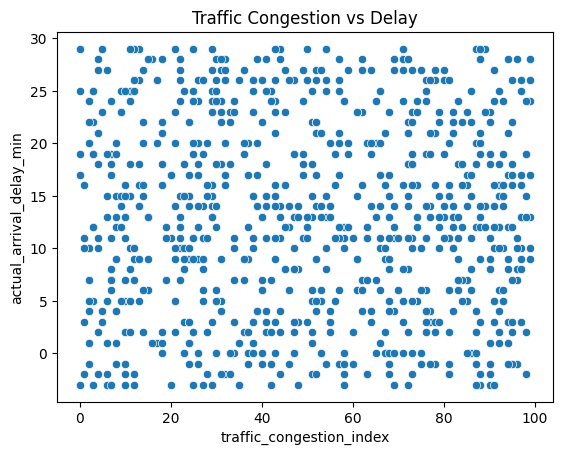

In [60]:
sns.scatterplot(x='traffic_congestion_index',
                y='actual_arrival_delay_min',
                data=df)

plt.title("Traffic Congestion vs Delay")

plt.show()

In [61]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

In [63]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 5.464277108433735
MSE: 43.49786204819277
R2 Score: 0.46527961033121046


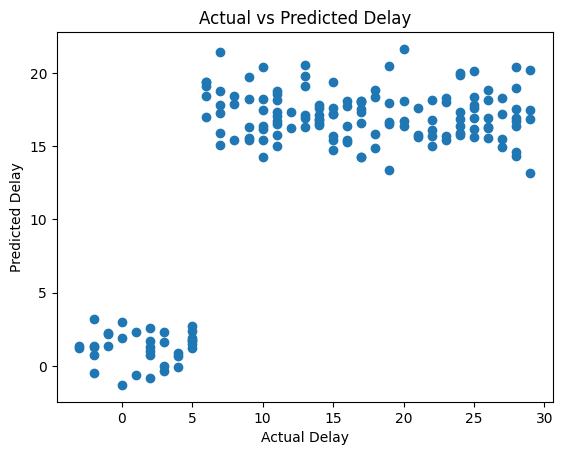

In [64]:
import matplotlib.pyplot as plt

plt.scatter(y_test, pred)

plt.xlabel("Actual Delay")
plt.ylabel("Predicted Delay")

plt.title("Actual vs Predicted Delay")

plt.show()

In [65]:
import pandas as pd

importance = model.feature_importances_

feature_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_df = feature_df.sort_values(by="Importance", ascending=False)

print(feature_df.head())

                     Feature  Importance
10                   delayed    0.597095
6   traffic_congestion_index    0.044005
4           precipitation_mm    0.043743
1              temperature_C    0.043272
2           humidity_percent    0.037519


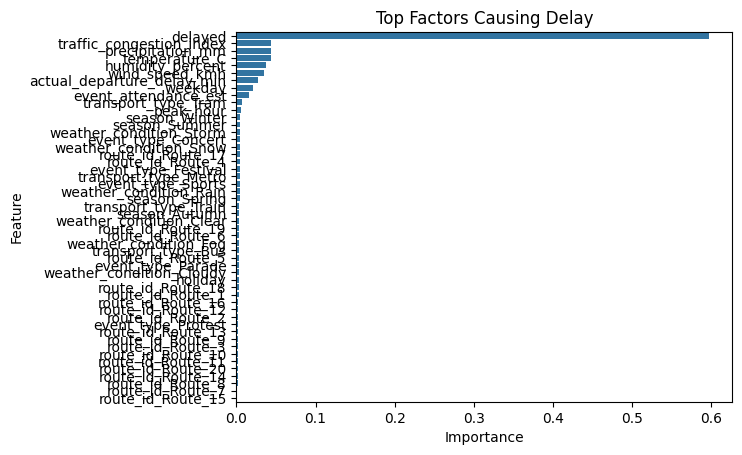

In [66]:
import seaborn as sns

sns.barplot(x="Importance", y="Feature", data=feature_df)

plt.title("Top Factors Causing Delay")

plt.show()

In [67]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 827 entries, 2 to 1996
Data columns (total 51 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   actual_departure_delay_min  827 non-null    int64  
 1   actual_arrival_delay_min    827 non-null    int64  
 2   temperature_C               827 non-null    float64
 3   humidity_percent            827 non-null    int64  
 4   wind_speed_kmh              827 non-null    int64  
 5   precipitation_mm            827 non-null    float64
 6   event_attendance_est        827 non-null    int64  
 7   traffic_congestion_index    827 non-null    int64  
 8   holiday                     827 non-null    int64  
 9   peak_hour                   827 non-null    int64  
 10  weekday                     827 non-null    int64  
 11  delayed                     827 non-null    int64  
 12  transport_type_Bus          827 non-null    bool   
 13  transport_type_Metro        827 non-nul

,actual_departure_delay_min,actual_arrival_delay_min,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,delayed
count,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000
mean,8.636034,13.022975,14.486336,64.499395,29.125756,9.818380,6616.082225,50.548972,0.082225,0.282950,2.922612,0.741233
std,6.185338,9.179312,11.703170,20.264616,17.084426,5.751976,15361.931191,29.173248,0.274873,0.450705,1.969823,0.438222
min,-2.000000,-3.000000,-5.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,5.000000,4.300000,46.000000,15.000000,4.900000,0.000000,25.500000,0.000000,0.000000,1.000000,0.000000
50%,9.000000,13.000000,14.400000,65.000000,29.000000,9.600000,0.000000,51.000000,0.000000,0.000000,3.000000,1.000000
75%,14.000000,20.500000,24.200000,82.000000,44.000000,14.800000,2000.000000,76.000000,0.000000,1.000000,5.000000,1.000000
max,19.000000,29.000000,35.000000,99.000000,59.000000,20.000000,50000.000000,99.000000,1.000000,1.000000,6.000000,1.000000


In [69]:
df.to_csv("transport_delay_cleaned.csv", index=False)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')